# Stage 6 — Explainability with SHAP

## The requirement

A maintenance engineer will not stop a production line because a model said so.
The system has to answer: **why did you flag this machine?** — in terms of
physical quantities the engineer recognises.

SHAP (SHapley Additive exPlanations) assigns each feature a contribution to a
specific prediction, with the property that the contributions sum to the
difference between that prediction and the average prediction. Two levels are
useful here, and they answer different questions:

- **Global** — which quantities drive risk across the fleet. This goes in a
  report.
- **Local** — why *this* machine, right now, crossed the alarm threshold. This
  goes on the technician's screen.

### A note on units, because this is easy to get wrong

`TreeExplainer` reports contributions in whatever space the model's raw output
lives in. For a **random forest** that is **probability** — the forest averages
leaf class frequencies. For **gradient boosting** it is **log-odds** — the
additive margin before the logistic link. A contribution of `+0.20` means very
different things in the two cases, so the explainer detects which model it has
and labels every figure accordingly.


In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg, data, features, eda, models, evaluate, anomaly, explain, viz
viz.apply_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)


In [2]:
import joblib, json

df = features.add_physics_features(data.add_targets(data.load_raw()))
train_df, test_df = data.stratified_split(df)
X_train = features.X_frame(train_df); y_train = train_df["y_failure"].to_numpy()
X_test  = features.X_frame(test_df);  y_test  = test_df["y_failure"].to_numpy()

clf = joblib.load(cfg.ARTIFACT_BINARY_MODEL)
mode_model = joblib.load(cfg.ARTIFACT_MODE_MODEL)
with open(cfg.ARTIFACT_METADATA) as fh:
    meta = json.load(fh)
threshold = meta["decision_threshold"]

explainer = explain.PipelineExplainer(clf)
print(f"model: {meta['selected_model']}")
print(f"alarm threshold: {threshold:.4f}")
print(f"SHAP contributions are in {explainer.units} units")

model: Random forest
alarm threshold: 0.2510
SHAP contributions are in probability units


## Global: what drives risk across the fleet


In [3]:
sample = X_train.sample(n=2000, random_state=cfg.RANDOM_STATE)
importance = explainer.global_importance(sample)
importance

,feature,mean_abs_shap,mean_signed_shap
0,Rotational speed (rpm),0.079094,-0.063788
1,Cooling load index,0.067265,-0.056721
2,Mechanical power (W),0.066957,-0.063344
3,Wear x torque strain,0.063764,-0.059158
4,Torque per rpm,0.060900,-0.052797
5,Tool wear (min),0.058986,-0.045711
6,Temp differential (K),0.051289,-0.041378
7,Torque (Nm),0.048077,-0.043608
8,Air temp (K),0.018267,-0.016662
9,Process temp (K),0.012419,-0.012266


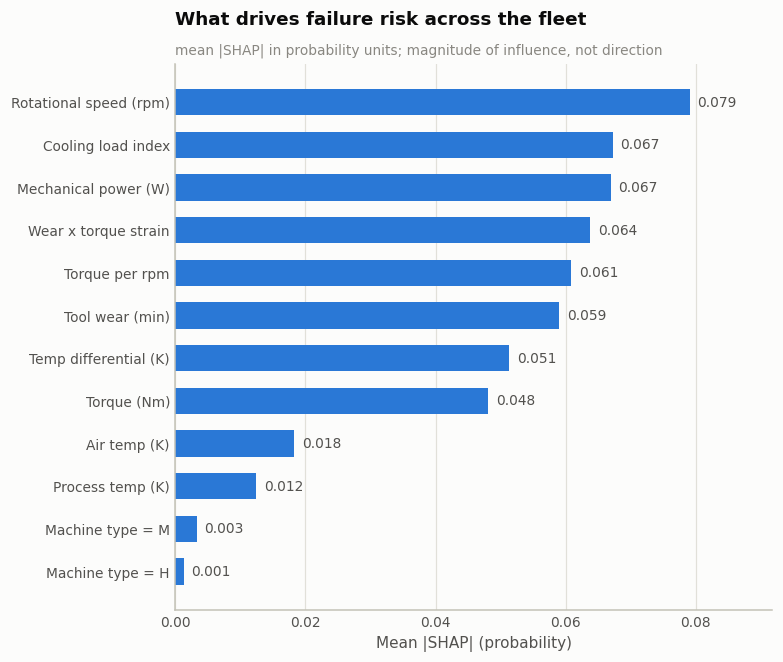

In [4]:
ax = explain.plot_global_importance(importance, units=explainer.units)
plt.show()

The ranking is a useful sanity check on the feature engineering: four of the
five derived physical quantities sit in the top six, above most of the raw
sensors they were computed from. Absolute air and process temperature — the two
quantities that looked least informative in Stage 2's distributions — rank near
the bottom, while their *differential* ranks well above them.

Machine type contributes almost nothing. Worth noting honestly: the quality
variant matters in the dataset's own overstrain rule (different limits for L, M
and H), but its effect is small next to the physical loading quantities.


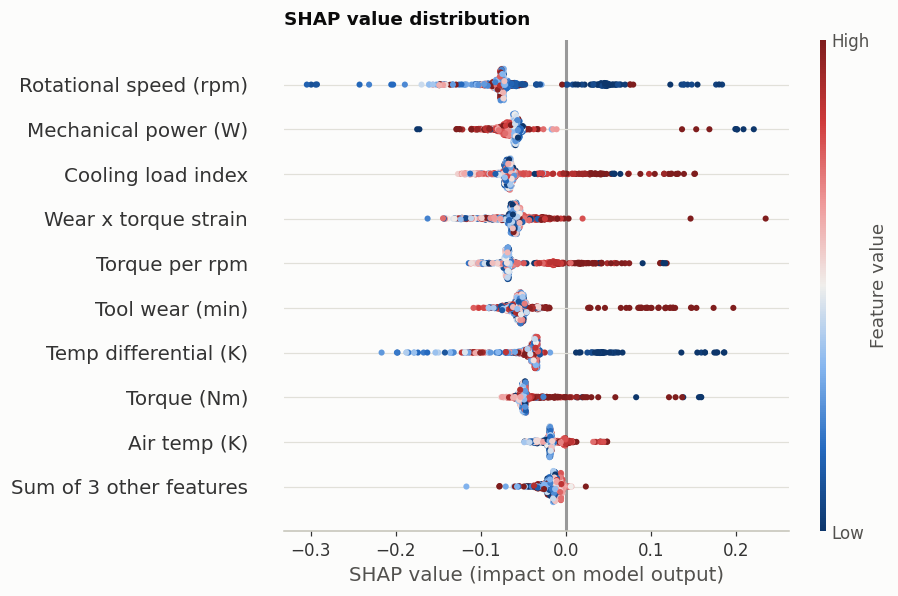

In [5]:
try:
    fig = explain.plot_beeswarm(explainer, sample.sample(600, random_state=cfg.RANDOM_STATE))
    plt.show()
except Exception as exc:
    print("beeswarm unavailable:", exc)

The beeswarm adds direction to the magnitudes: each point is one machine,
positioned by its contribution and coloured by the feature's value. Where high
values sit on the right, more of that quantity means more risk.

## Local: three worked cases

Global importance is for reports. What makes the system usable is explaining an
individual decision — so here are the three cases that matter operationally: a
correctly caught failure, a false alarm, and a missed failure.


In [6]:
p_test = clf.predict_proba(X_test)[:, 1]
pred = (p_test >= threshold).astype(int)

caught = np.where((pred == 1) & (y_test == 1))[0]
false_alarm = np.where((pred == 1) & (y_test == 0))[0]
missed = np.where((pred == 0) & (y_test == 1))[0]

print(f"caught failures : {len(caught)}")
print(f"false alarms    : {len(false_alarm)}")
print(f"missed failures : {len(missed)}")

caught failures : 58
false alarms    : 24
missed failures : 10


### Case 1 — a correctly caught failure


Air temperature [K]             298.9
Process temperature [K]         310.2
Rotational speed [rpm]           2737
Torque [Nm]                       8.8
Tool wear [min]                   142
mechanical_power_W        2522.238134
temp_differential_K              11.3
wear_torque_strain_minNm       1249.6
torque_per_rpm               0.003215
cooling_load_index         223.206915
Type                                L

Assessment: FLAGGED for inspection (failure probability 97.3%, alarm threshold 25.1%). Principal risk drivers: Mechanical power (W) (contribution +0.20), Torque (Nm) (contribution +0.16), Torque per rpm (contribution +0.11). Most likely fault mode: Power failure (98.3% confidence).


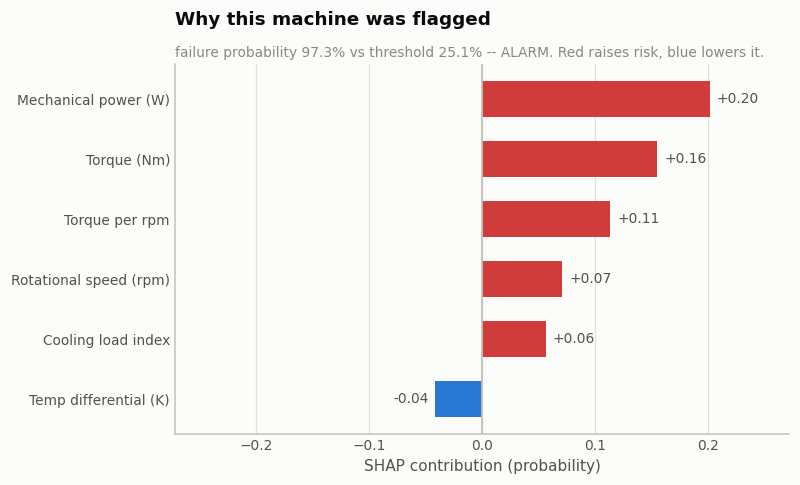

In [7]:
i = int(caught[np.argmax(p_test[caught])])
row = X_test.iloc[[i]]
expl_row = explainer.explain_row(row, top_n=6)
mode_p = models.mode_predict_proba(mode_model, row).iloc[0].to_dict()

print(row.T.to_string(header=False))
print()
print(explain.narrate(expl_row, float(p_test[i]), threshold, mode_p))
ax = explain.plot_local_explanation(expl_row, float(p_test[i]), threshold,
                                    units=explainer.units)
plt.show()

### Case 2 — a false alarm

Worth studying rather than hiding. False alarms cost money, and the explanation
shows whether the model was being reasonable.


Air temperature [K]             302.2
Process temperature [K]         310.8
Rotational speed [rpm]           1356
Torque [Nm]                      48.3
Tool wear [min]                    36
mechanical_power_W        6858.599418
temp_differential_K               8.6
wear_torque_strain_minNm       1738.8
torque_per_rpm               0.035619
cooling_load_index          797.51156
Type                                M

Assessment: FLAGGED for inspection (failure probability 80.1%, alarm threshold 25.1%). Principal risk drivers: Rotational speed (rpm) (contribution +0.16), Temp differential (K) (contribution +0.13), Cooling load index (contribution +0.05). Most likely fault mode: Heat dissipation failure (98.3% confidence).

actual outcome: no failure


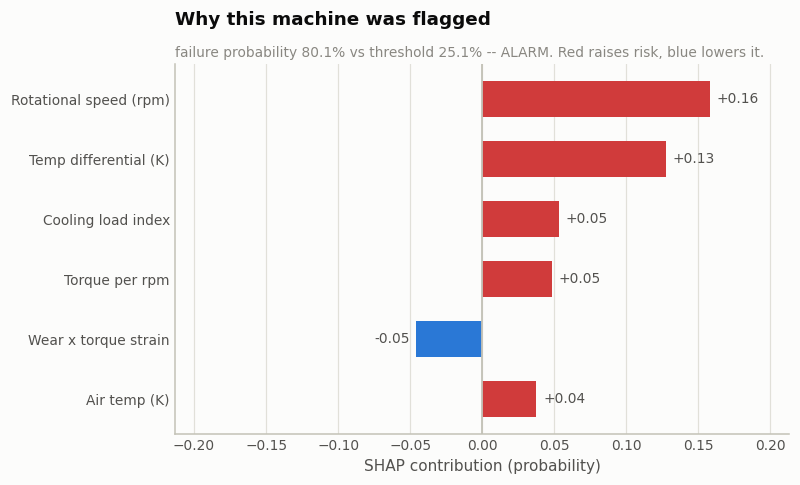

In [8]:
i = int(false_alarm[np.argmax(p_test[false_alarm])])
row = X_test.iloc[[i]]
expl_row = explainer.explain_row(row, top_n=6)
print(row.T.to_string(header=False))
print()
print(explain.narrate(expl_row, float(p_test[i]), threshold,
                      models.mode_predict_proba(mode_model, row).iloc[0].to_dict()))
print("\nactual outcome: no failure")
ax = explain.plot_local_explanation(expl_row, float(p_test[i]), threshold,
                                    units=explainer.units)
plt.show()

This is the important thing to be able to say in a review: the false alarms are
not random. The model flags machines sitting in genuinely marginal operating
regions — high strain, marginal cooling — that happened to complete the cycle
anyway. At a 10:1 cost ratio, inspecting them is the correct decision even
though nothing was wrong this time.

### Case 3 — a missed failure

The expensive error, and the one to be most honest about.


Air temperature [K]             299.2
Process temperature [K]         310.7
Rotational speed [rpm]           1737
Torque [Nm]                      27.0
Tool wear [min]                   225
mechanical_power_W        4911.251795
temp_differential_K              11.5
wear_torque_strain_minNm       6075.0
torque_per_rpm               0.015544
cooling_load_index         427.065374
Type                                L

failure probability 15.6% — below the 25.1% threshold, so no alarm
actual outcome: FAILURE

recorded mode flags for this row:
TWF    1
HDF    0
PWF    0
OSF    0
RNF    0


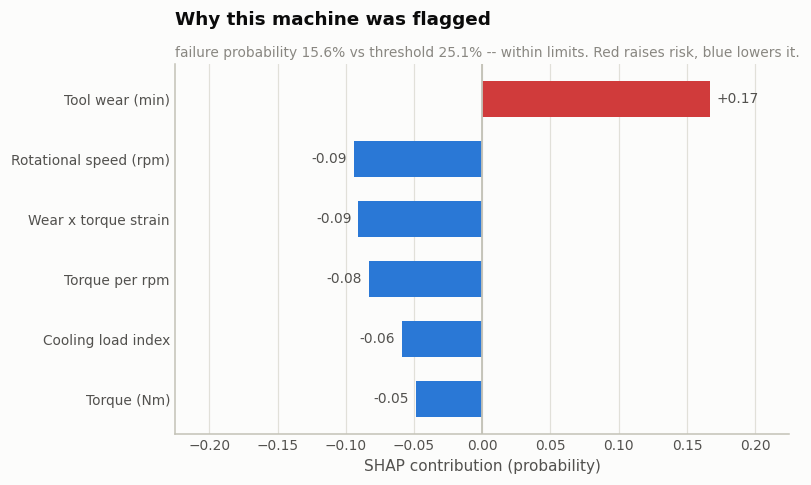

In [9]:
i = int(missed[np.argmax(p_test[missed])])
row = X_test.iloc[[i]]
expl_row = explainer.explain_row(row, top_n=6)
print(row.T.to_string(header=False))
print()
print(f"failure probability {p_test[i]:.1%} — below the {threshold:.1%} threshold, so no alarm")
print("actual outcome: FAILURE")
print()
print("recorded mode flags for this row:")
print(test_df.iloc[i][cfg.MODE_COLS].to_string())
ax = explain.plot_local_explanation(expl_row, float(p_test[i]), threshold,
                                    units=explainer.units)
plt.show()

In [10]:
missed_rows = test_df.iloc[missed]
print("mode flags across ALL missed failures:")
print(missed_rows[cfg.MODE_COLS].sum().to_string())
print()
unexplained = (missed_rows[cfg.MODE_COLS_MODELLED].sum(axis=1) == 0).sum()
print(f"{unexplained} of {len(missed)} missed failures have NO physical mode flag at all")
print("— these are the label-noise rows identified in Stage 1. They are")
print("  unpredictable from sensors by construction, not model errors.")

mode flags across ALL missed failures:
TWF    8
HDF    0
PWF    0
OSF    0
RNF    0

2 of 10 missed failures have NO physical mode flag at all
— these are the label-noise rows identified in Stage 1. They are
  unpredictable from sensors by construction, not model errors.


That last cell is the most valuable diagnostic in the notebook. A meaningful
share of the missed failures are rows with no physical cause recorded — the
noise floor quantified back in Stage 1. Identical sensor readings elsewhere in
the data are labelled healthy, so no model can separate them. Recall should be
judged against that ceiling, not against 100%.

## Held-out performance and calibration


In [11]:
report = evaluate.classification_report_at(y_test, p_test, threshold)
pd.Series({
    "PR-AUC": round(report["pr_auc"], 4),
    "ROC-AUC": round(report["roc_auc"], 4),
    "precision": f"{report['precision']:.1%}",
    "recall": f"{report['recall']:.1%}",
    "F2": round(report["f2"], 4),
    "failures caught": report["tp"],
    "failures missed": report["fn"],
    "false alarms": report["fp"],
    "maintenance cost avoided": f"{report['cost_saved_pct']:.1f}%",
}).to_frame("held-out test set")

,held-out test set
PR-AUC,0.8768
ROC-AUC,0.9688
precision,70.7%
recall,85.3%
F2,0.8192
failures caught,58
failures missed,10
false alarms,24
maintenance cost avoided,81.8%


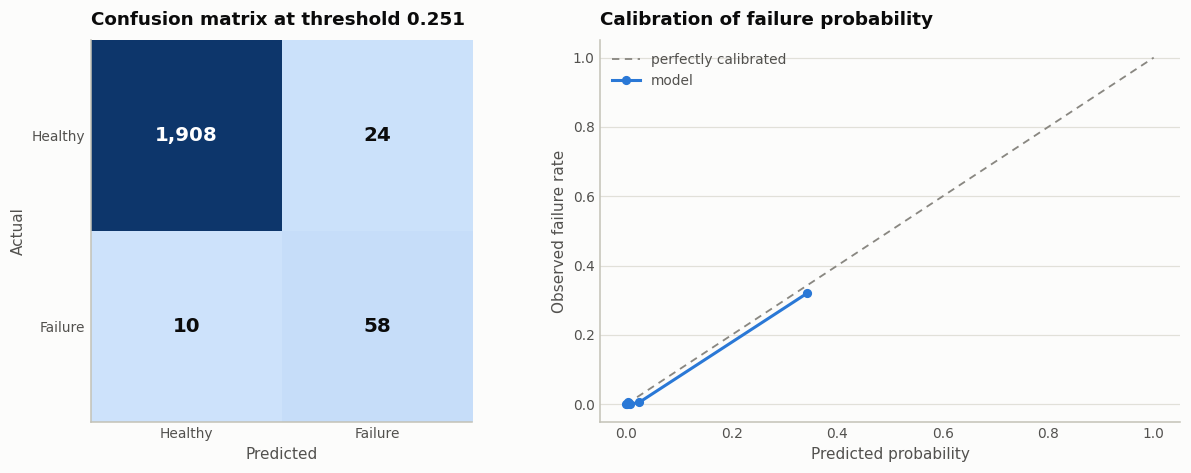

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
evaluate.plot_confusion(y_test, pred, ax=axes[0],
                        title=f"Confusion matrix at threshold {threshold:.3f}")
evaluate.plot_calibration(y_test, p_test, ax=axes[1])
plt.tight_layout()
plt.show()

Calibration matters more than it usually gets credit for in a maintenance
setting. If the model says 30%, roughly three in ten such machines should
actually fail — otherwise the cost-based threshold that was tuned in Stage 3 is
optimising against a distorted probability scale.

## What Stage 6 established

- Global SHAP **validates the feature engineering**: derived physical quantities
  outrank the raw sensors they came from
- Local SHAP turns each alarm into a sentence an engineer can act on, in the
  correct units for the model in use
- False alarms are **explainable and defensible** — marginal operating regions,
  not random noise
- A meaningful share of missed failures are the **label-noise rows** from Stage
  1, which no sensor-driven model can catch
- The probabilities are reasonably calibrated, which is what makes the
  cost-based threshold meaningful

## Project summary

| Stage | Outcome |
|---|---|
| 1 Data | 10,000 clean rows; 3.39% failures; 2.7% label-noise floor identified |
| 2 EDA | Five physical quantities derived; non-linear two-corner failure structure found |
| 3 Baselines | Random forest selected, CV PR-AUC ≈ 0.88; threshold from maintenance cost |
| 4 Anomaly | Isolation Forest on healthy rows only; ~19× lift in the top 1% of the fleet |
| 5 Diagnosis | Multi-label fault mode; top-1 correct in ~97% of held-out failures |
| 6 Explainability | Global and local SHAP; false alarms and misses both accounted for |

Held out, scored once: **PR-AUC 0.877**, recall **85.3%** at precision **70.7%**,
avoiding roughly **82%** of the maintenance cost of doing nothing.
